Titanic Survival Prediction using Naive Bayes Classification

Saving titanic.csv to titanic (2).csv
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0         

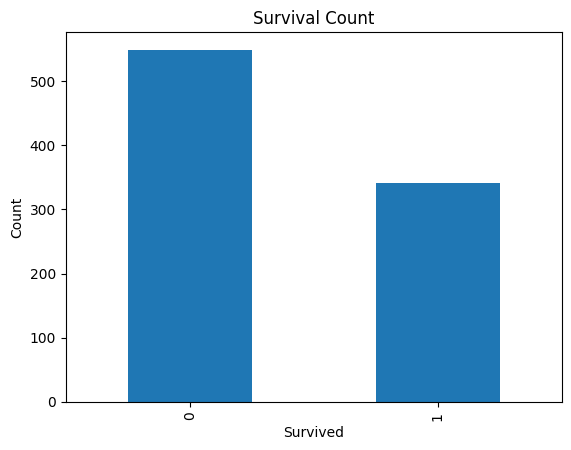

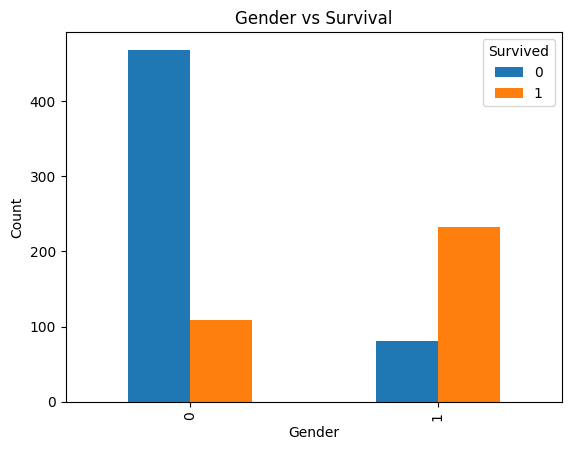

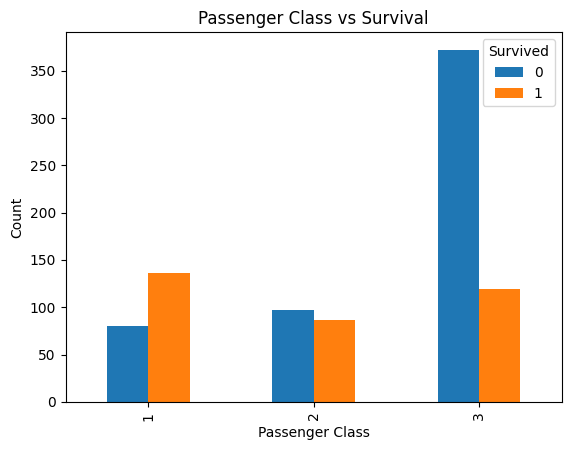

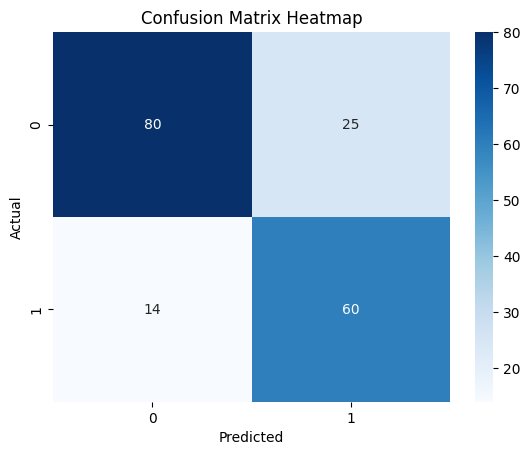

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Upload Dataset
uploaded = files.upload()

# Load Dataset
data = pd.read_csv('train.csv')

# Display First 5 Rows
print(data.head())

# Data Cleaning
data['Age'] = data['Age'].fillna(data['Age'].median())

data['Fare'] = data['Fare'].fillna(data['Fare'].median())

data['Embarked'] = data['Embarked'].fillna(
    data['Embarked'].mode()[0]
)

# Drop Unnecessary Columns
data.drop(
    ['Cabin', 'Ticket', 'PassengerId'],
    axis=1,
    inplace=True
)

# Feature Engineering
data['FamilySize'] = (
    data['SibSp'] +
    data['Parch'] + 1
)

data['IsAlone'] = 0

data.loc[
    data['FamilySize'] == 1,
    'IsAlone'
] = 1

# Extract Title from Name
data['Title'] = data['Name'].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

# Replace Rare Titles
data['Title'] = data['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col',
     'Don', 'Dr', 'Major', 'Rev',
     'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)

# Replace Similar Titles
data['Title'] = data['Title'].replace(
    ['Mlle', 'Ms'],
    'Miss'
)

data['Title'] = data['Title'].replace(
    'Mme',
    'Mrs'
)

# Convert Categorical Data to Numeric

# Encode Gender
data['Sex'] = data['Sex'].map({
    'male': 0,
    'female': 1
})

# Encode Embarked
data['Embarked'] = data['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

# Encode Title
title_mapping = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Rare': 5
}

data['Title'] = data['Title'].map(
    title_mapping
)

data['Title'] = data['Title'].fillna(0)

# Age Binning
data['AgeBand'] = pd.cut(
    data['Age'],
    5,
    labels=[0, 1, 2, 3, 4]
)

# Fare Binning
data['FareBand'] = pd.qcut(
    data['Fare'],
    4,
    labels=[0, 1, 2, 3]
)

# Feature Selection
X = data[
    ['Pclass',
     'Sex',
     'FamilySize',
     'IsAlone',
     'Embarked',
     'Title',
     'AgeBand',
     'FareBand']
]

y = data['Survived']

# Convert Features to Integer
X = X.astype(int)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train Naive Bayes Model
model = GaussianNB()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, y_pred))

# Survival Count Graph
data['Survived'].value_counts().plot(
    kind='bar'
)

plt.title("Survival Count")

plt.xlabel("Survived")

plt.ylabel("Count")

plt.show()

# Gender vs Survival Graph
survival_gender = pd.crosstab(
    data['Sex'],
    data['Survived']
)

survival_gender.plot(kind='bar')

plt.title("Gender vs Survival")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

# Passenger Class vs Survival Graph
class_survival = pd.crosstab(
    data['Pclass'],
    data['Survived']
)

class_survival.plot(kind='bar')

plt.title("Passenger Class vs Survival")

plt.xlabel("Passenger Class")

plt.ylabel("Count")

plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix Heatmap")

plt.show()